# Cloud ML Deployment — Concepts, Options, and Costs

Running a model on your laptop is useful during development. Deploying it to the cloud means real users can call it 24/7, from anywhere, at any scale — without you managing physical servers.

This notebook covers:
- What cloud deployment adds over local serving
- The three main deployment options and when to pick each
- The full deployment lifecycle
- A simple cost model for estimating cloud spend

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 4, lesson 12 "12. CPU vs GPU Machine Learning" — you priced one workload against two kinds of hardware and chose on measured benefit; cloud deployment is that same trade-off at the level of rented instances, hours and request volume.

**Used later in:** Course 12 (AIAT 126) — Unit 1, lesson 01 "Project Proposal and Literature Review", whose success criteria include a deployed web application that is accessible and functional.


## 📰 In Saudi Arabia, "which region?" is a legal question before it is a technical one

The Kingdom's **Personal Data Protection Law (PDPL)** came into force on **14 September 2023**, and controllers had until **14 September 2024** — a one-year grace period — to comply; SDAIA has been enforcing it since. Alongside the PDPL sit its **Implementing Regulations** and a separate **Regulation on Personal Data Transfer Outside the Kingdom**: as a general rule personal data may not leave Saudi Arabia unless specific legal conditions are met, and meeting them is a documented compliance step, not a default. Meanwhile the infrastructure side moved too — **Google Cloud runs a Dammam region (`me-central2`)**, which its own documentation says KSA-based customers reach by contracting through CNTXT, and the other major providers have been building in-Kingdom capacity as well.

Put those two facts together and the picture for a graduate deploying a model here is concrete: for a hospital, a bank or a government body, the region dropdown in a deployment console is where a legal obligation is either satisfied or breached. `us-east-1` is not a default. It is a decision with a regulator attached.

**What goes wrong without this lesson.** A model that runs beautifully on a laptop reaches nobody. Moving it to the cloud is where four separate questions arrive at once — how much will this cost per request, what happens when the instance dies, where is the data allowed to live, and who patches the operating system. Teams that answer only the first one end up with an endpoint that is cheap, unavailable, and non-compliant.

## Learning Objectives

By the end of this notebook you will be able to:
1. Name three cloud deployment options and explain the trade-offs between them
2. Train, save, and package a model artifact for cloud deployment
3. Simulate a cloud storage upload step and explain what it replaces in production
4. Estimate the cost difference between on-demand and spot pricing for a given request volume

## 1. What Cloud Deployment Adds

| Capability | Local server | Cloud managed endpoint |
|---|---|---|
| Scaling to traffic spikes | Manual — restart with more workers | Automatic horizontal scaling |
| Global availability | Single region | Multi-region, CDN-backed |
| SLA / uptime guarantee | None | 99.9 – 99.99% |
| Infrastructure patching | You do it | Provider does it |
| Billing | Fixed server cost | Pay per request / per hour |

The cost of managed services is higher per compute unit, but the operational overhead is dramatically lower.

## 2. The Three Deployment Options

**Option A — Raw VM (EC2 / Compute Engine / Azure VM)**
- You rent a virtual machine, install Python, run your FastAPI/Flask server yourself
- Full control, but you manage OS updates, scaling, load balancers, and monitoring
- Best for: custom hardware needs, legacy constraints, very predictable traffic

**Option B — Managed containers (ECS / GKE / AKS)**
- You build a Docker image, push it to a registry, define scaling rules
- The cloud orchestrator manages where and how many containers run
- Best for: teams already using Docker, need for flexibility without full server ops

**Option C — Managed ML endpoints (SageMaker / Vertex AI / Azure ML)**
- You upload a model artifact + inference script; the platform handles everything else
- Built-in A/B testing, model monitoring, auto-scaling, integrated billing
- Best for: pure ML teams who want to ship fast without DevOps expertise

> **Container images in 60 seconds** (needed for Options B and C, taught fully in Unit 4):
> a **container image** is a frozen snapshot of an application plus everything it needs to run — OS libraries, Python, packages, your code. A **container** is a running instance of an image, and a **registry** is the store images are pushed to and pulled from. Every managed ML endpoint in this unit (SageMaker, Azure ML, Vertex AI) runs your model *inside a provider-supplied container image* — you hand over the model artifact, the provider supplies the packaged runtime. Unit 4 teaches you to build your own images with Docker; until then, treat the image as a ready-made box the cloud runs for you.

## 3. Train and Save a Model Artifact

In [1]:
# WHAT: train the iris model and bundle model + scaler + class names in ONE artifact.
# WHY: cloud deployment ships files, not Python sessions — everything inference
# needs must travel together inside the artifact we are about to 'upload'.
import numpy as np
import joblib
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale and train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_s, y_train)

acc = accuracy_score(y_test, clf.predict(X_test_s))
print(f"Test accuracy: {acc:.2%}")

# Save model + scaler together as a pipeline artifact
artifact = {'model': clf, 'scaler': scaler, 'classes': iris.target_names.tolist()}
joblib.dump(artifact, '/tmp/iris_rf_artifact.joblib')
print("Artifact saved: /tmp/iris_rf_artifact.joblib")

Test accuracy: 100.00%
Artifact saved: /tmp/iris_rf_artifact.joblib


## 4. Simulate a Cloud Storage Upload

In production the model artifact goes to object storage first:
- **AWS**: S3 bucket (`s3://my-bucket/models/iris/v1/`)
- **GCP**: Google Cloud Storage (`gs://my-bucket/models/iris/v1/`)
- **Azure**: Blob Storage (`https://account.blob.core.windows.net/models/`)

The managed ML service then pulls the artifact from there. We simulate this with a local temp directory.

In [2]:
# WHAT: 'upload' the artifact to a simulated bucket (a local folder) and checksum it.
# WHY: the workflow — copy to durable storage, verify integrity, keep a versioned
# path — is exactly what boto3/gsutil do; only the transport differs.
import shutil
import pathlib
import hashlib

# Simulate cloud storage as a local directory
SIMULATED_BUCKET = pathlib.Path('/tmp/simulated_cloud_storage/models/iris/v1')
SIMULATED_BUCKET.mkdir(parents=True, exist_ok=True)

# Stand-in for s3.upload_file(): copy the file and prove it arrived intact.
def simulate_upload(local_path, destination_bucket):
    """Mirrors what boto3 s3.upload_file() or gsutil cp would do."""
    src = pathlib.Path(local_path)
    dst = destination_bucket / src.name
    shutil.copy2(src, dst)

    # Compute checksum to verify integrity (same as S3 ETag)
    md5 = hashlib.md5(dst.read_bytes()).hexdigest()
    size_kb = dst.stat().st_size / 1024
    print(f"Uploaded: {dst}")
    print(f"  Size  : {size_kb:.1f} KB")
    print(f"  MD5   : {md5}")
    return str(dst)

artifact_path = simulate_upload('/tmp/iris_rf_artifact.joblib', SIMULATED_BUCKET)

# The real AWS call, shown for comparison with the simulation above.
print("\nIn production this would be:")
print("  import boto3")
print("  s3 = boto3.client('s3')")
print("  s3.upload_file('iris_rf_artifact.joblib', 'my-bucket', 'models/iris/v1/iris_rf_artifact.joblib')")

Uploaded: /tmp/simulated_cloud_storage/models/iris/v1/iris_rf_artifact.joblib
  Size  : 183.0 KB
  MD5   : 18615c8ad95a1dcdf9678f89a67c196c

In production this would be:
  import boto3
  s3 = boto3.client('s3')
  s3.upload_file('iris_rf_artifact.joblib', 'my-bucket', 'models/iris/v1/iris_rf_artifact.joblib')


## 5. Cost Model — On-Demand vs Spot Pricing

Cloud providers offer two pricing modes:
- **On-demand**: fixed hourly rate, instance available whenever you need it
- **Spot / Preemptible**: up to 90% cheaper, but the instance can be terminated with 2 minutes notice

For inference endpoints that must always be available, on-demand (or reserved) instances are required. Spot is great for batch jobs.

In [3]:
# Cost model for serving 1 million predictions per day

# Instance specs (ml.m5.large equivalent)
ON_DEMAND_PER_HOUR = 0.115   # USD
SPOT_PER_HOUR      = 0.034   # USD (~70% discount)

# Throughput assumptions
REQUESTS_PER_DAY   = 1_000_000
REQUESTS_PER_HOUR  = REQUESTS_PER_DAY / 24
REQUESTS_PER_SECOND = REQUESTS_PER_HOUR / 3600

# One instance handles ~50 req/s for a simple sklearn model
CAPACITY_PER_INSTANCE = 50
INSTANCES_NEEDED = max(1, int(REQUESTS_PER_SECOND / CAPACITY_PER_INSTANCE) + 1)

hours_per_month = 24 * 30
on_demand_monthly = INSTANCES_NEEDED * ON_DEMAND_PER_HOUR * hours_per_month
spot_monthly = INSTANCES_NEEDED * SPOT_PER_HOUR * hours_per_month

cost_per_million_on_demand = (on_demand_monthly / (REQUESTS_PER_DAY * 30)) * 1_000_000
cost_per_million_spot = (spot_monthly / (REQUESTS_PER_DAY * 30)) * 1_000_000

print(f"Daily request volume  : {REQUESTS_PER_DAY:,}")
print(f"Peak req/s            : {REQUESTS_PER_SECOND:.1f}")
print(f"Instances needed      : {INSTANCES_NEEDED}")
print()
print(f"On-demand monthly cost: ${on_demand_monthly:,.2f}")
print(f"Spot monthly cost     : ${spot_monthly:,.2f}")
print(f"Savings with spot     : ${on_demand_monthly - spot_monthly:,.2f} ({(1-spot_monthly/on_demand_monthly)*100:.0f}%)")
print()
print(f"Cost per 1M predictions (on-demand): ${cost_per_million_on_demand:.4f}")
print(f"Cost per 1M predictions (spot)     : ${cost_per_million_spot:.4f}")
print()
print("WARNING: Spot instances can be terminated with 2 min notice.")
print("Never use spot-only for always-on inference endpoints.")

Daily request volume  : 1,000,000
Peak req/s            : 11.6
Instances needed      : 1

On-demand monthly cost: $82.80
Spot monthly cost     : $24.48
Savings with spot     : $58.32 (70%)

Cost per 1M predictions (on-demand): $2.7600
Cost per 1M predictions (spot)     : $0.8160

Never use spot-only for always-on inference endpoints.


### Reading the cost model as a curve

The cell above priced exactly one volume. Two questions it cannot answer from a single row: what happens to the bill as traffic grows, and what does a real day of that traffic actually look like? Both are one plot each, built from the same three constants the cost model just used.

One instance covers everything up to 4,466,836 requests/day.
Cost at 10,000 req/day  : $82.80/month on-demand
Cost at 1,000,000 req/day: $82.80/month on-demand  (identical)

Peak hour   : 28.5 req/s
Daily mean  : 11.6 req/s
Peak / mean : 2.46x


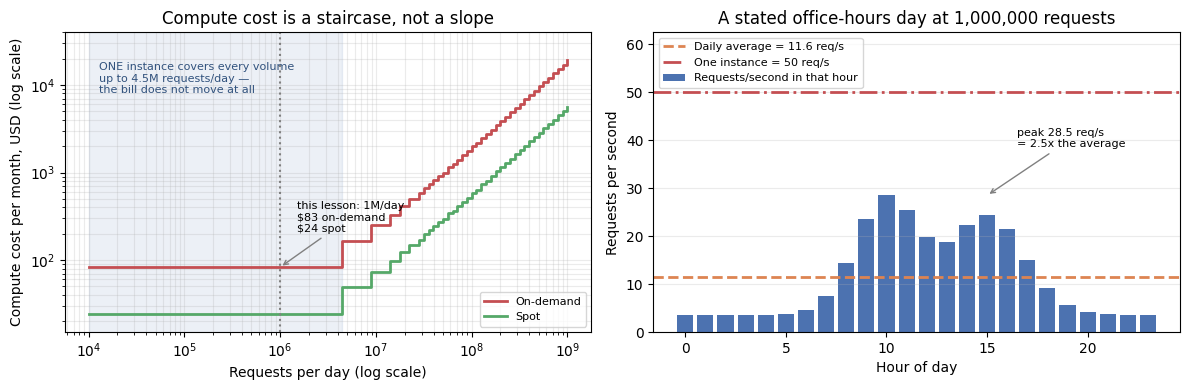

In [4]:
# WHAT: draw the cost model instead of only printing it — monthly cost against
# daily request volume, and the shape of a real day's traffic.
# WHY: the printout gave one row of the table; the curve shows where the money
# actually goes, and the day profile shows why "requests per day / 86400" is a
# dangerous way to size a service.
import numpy as np
import matplotlib.pyplot as plt

# --- Left panel: cost as daily volume grows -------------------------------
# Same three constants as the cost cell above, reused so the curve and the
# printout cannot disagree.
def instances_for(reqs_per_day):
    rps = reqs_per_day / 86400.0
    return max(1, int(rps / CAPACITY_PER_INSTANCE) + 1)

volumes = np.array([10 ** e for e in np.arange(4, 9.01, 0.05)])
inst = np.array([instances_for(v) for v in volumes])
cost_on_demand = inst * ON_DEMAND_PER_HOUR * hours_per_month
cost_spot = inst * SPOT_PER_HOUR * hours_per_month

# The volume at which one instance is no longer enough
first_step = volumes[np.argmax(inst > 1)]

# --- Right panel: one day of traffic, not a flat average ------------------
# A STATED office-hours shape (two peaks), not measured traffic: it exists to
# show the peak-to-mean ratio, which is the number that sizes a service.
hours = np.arange(24)
shape = 0.15 + np.exp(-((hours - 10.0) / 2.2) ** 2) + 0.85 * np.exp(-((hours - 15.0) / 2.6) ** 2)
shape = shape / shape.sum()
rps_by_hour = shape * REQUESTS_PER_DAY / 3600.0
peak_rps = rps_by_hour.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.step(volumes, cost_on_demand, where='post', color='#C44E52', lw=2, label='On-demand')
ax.step(volumes, cost_spot, where='post', color='#55A868', lw=2, label='Spot')
ax.axvspan(1e4, first_step, color='#4C72B0', alpha=0.10)
ax.axvline(REQUESTS_PER_DAY, color='gray', ls=':', lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(15, 4e4)
ax.text(1.3e4, 8e3, f'ONE instance covers every volume\nup to {first_step/1e6:.1f}M requests/day —\nthe bill does not move at all',
        fontsize=8, color='#31527d')
ax.annotate(f'this lesson: 1M/day\n${on_demand_monthly:,.0f} on-demand\n${spot_monthly:,.0f} spot',
            xy=(REQUESTS_PER_DAY, on_demand_monthly), xytext=(1.5e6, 210),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Requests per day (log scale)')
ax.set_ylabel('Compute cost per month, USD (log scale)')
ax.set_title('Compute cost is a staircase, not a slope')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.25, which='both')

ax = axes[1]
ax.bar(hours, rps_by_hour, color='#4C72B0', width=0.8, label='Requests/second in that hour')
ax.axhline(REQUESTS_PER_SECOND, color='#DD8452', ls='--', lw=2,
           label=f'Daily average = {REQUESTS_PER_SECOND:.1f} req/s')
ax.axhline(CAPACITY_PER_INSTANCE, color='#C44E52', ls='-.', lw=2,
           label=f'One instance = {CAPACITY_PER_INSTANCE} req/s')
ax.annotate(f'peak {peak_rps:.1f} req/s\n= {peak_rps/REQUESTS_PER_SECOND:.1f}x the average',
            xy=(15, peak_rps), xytext=(16.5, peak_rps + 10), fontsize=8,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Hour of day')
ax.set_ylabel('Requests per second')
ax.set_title(f'A stated office-hours day at {REQUESTS_PER_DAY:,} requests')
ax.set_ylim(0, CAPACITY_PER_INSTANCE * 1.25)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()

print(f"One instance covers everything up to {first_step:,.0f} requests/day.")
print(f"Cost at 10,000 req/day  : ${cost_on_demand[0]:,.2f}/month on-demand")
print(f"Cost at 1,000,000 req/day: ${cost_on_demand[np.argmin(abs(volumes-1e6))]:,.2f}/month on-demand  (identical)")
print()
print(f"Peak hour   : {peak_rps:.1f} req/s")
print(f"Daily mean  : {REQUESTS_PER_SECOND:.1f} req/s")
print(f"Peak / mean : {peak_rps/REQUESTS_PER_SECOND:.2f}x")
plt.show()


**🔍 Read the figure.** *Left panel:* the on-demand line is **flat at $82.80/month all the way from 10,000 to 4.5 million requests a day** — a 450x change in traffic with no change at all in the compute bill, because one `ml.m5.large` absorbs every one of those volumes. Compute is not what makes a small ML service expensive; the "⚠️ Where this breaks" section below lists what is. Past that point the line becomes a staircase, one step per additional instance, and the spot line is the same staircase at roughly 30% of the height — the 70% saving holds at every volume, and so does the two-minute termination notice.

*Right panel:* the same one million daily requests, spread across a stated office-hours day. The daily average is **11.6 requests/second** (orange line) but the busiest hour runs at **28.5 requests/second — 2.5x the average**. At this volume one instance (50 req/s, the red line) still covers even the peak, so the flat calculation happens to survive here. The **ratio** is what to carry away: any service whose *average* is above roughly 20 req/s will be sized at one instance by the "requests per day ÷ 86,400" arithmetic and will be short of capacity at 3pm.

## 💬 Discuss

The cost model just put numbers on the trade: **$82.80/month on-demand versus $24.48 on spot** for one million predictions a day — a 70% saving, on an instance that can be reclaimed with two minutes' notice.

1. That 70% is a large number. Construct the workload where you would take it anyway — and be honest about what "the instance disappears mid-request" means for your users in that case. Is there a design that gets most of the saving without the risk?
2. Our model says "1 instance" for both 10,000 and 1,000,000 requests per day, because 11.6 requests/second fits comfortably in one box. What does that tell you about where the real cost of a small ML service comes from? If compute is not the driver, what is?
3. Under the PDPL rules above, a Saudi hospital wants a diagnostic model deployed on a managed ML endpoint. Rank the three options in section 2 for *this* client, and say what you would need to confirm about the provider's region before signing anything.

## 6. Deployment Lifecycle Diagram

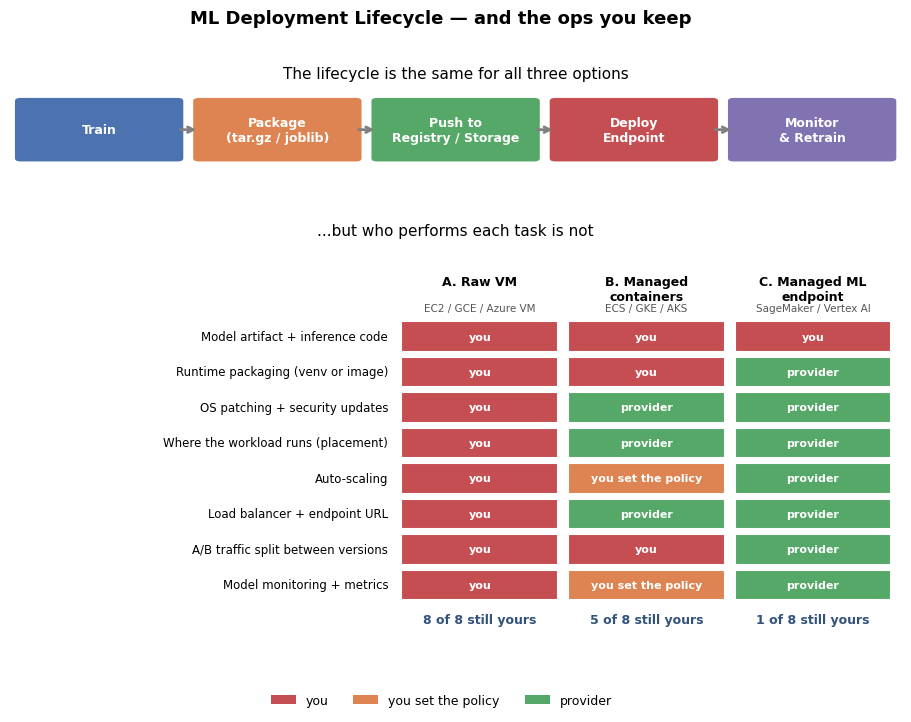

Boxes you still own — VM: 8, containers: 5, managed endpoint: 1 (of 8)


In [5]:
# WHAT: draw the 5-stage lifecycle AND, underneath it, who actually performs each
# task under each of the three deployment options from section 2.
# WHY: the lifecycle strip alone is the same for all three options, so on its own it
# hides the real decision. The grid below is the decision: the three options differ
# only in how many of these boxes stay yours.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

stages = [
    ('Train', '#4C72B0'),
    ('Package\n(tar.gz / joblib)', '#DD8452'),
    ('Push to\nRegistry / Storage', '#55A868'),
    ('Deploy\nEndpoint', '#C44E52'),
    ('Monitor\n& Retrain', '#8172B2'),
]

# Ownership per task, read straight off the option descriptions in section 2.
# 'you' = you build and run it, 'cfg' = you choose the policy, the provider runs it,
# 'prov' = the provider does it and you never see it.
OPTIONS = [('A. Raw VM\n ', 'EC2 / GCE / Azure VM'),
           ('B. Managed\ncontainers', 'ECS / GKE / AKS'),
           ('C. Managed ML\nendpoint', 'SageMaker / Vertex AI')]
tasks = [
    ('Model artifact + inference code',       'you',  'you',  'you'),
    ('Runtime packaging (venv or image)',     'you',  'you',  'prov'),
    ('OS patching + security updates',        'you',  'prov', 'prov'),
    ('Where the workload runs (placement)',   'you',  'prov', 'prov'),
    ('Auto-scaling',                          'you',  'cfg',  'prov'),
    ('Load balancer + endpoint URL',          'you',  'prov', 'prov'),
    ('A/B traffic split between versions',    'you',  'you',  'prov'),
    ('Model monitoring + metrics',            'you',  'cfg',  'prov'),
]
COLORS = {'you': '#C44E52', 'cfg': '#DD8452', 'prov': '#55A868'}
LABELS = {'you': 'you', 'cfg': 'you set the policy', 'prov': 'provider'}

fig = plt.figure(figsize=(11.5, 7.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 3.4], hspace=0.28)

# --- Top: the lifecycle itself, identical whichever option you pick -----------
ax = fig.add_subplot(gs[0])
ax.set_xlim(0, len(stages)); ax.set_ylim(0, 1); ax.axis('off')
for i, (label, color) in enumerate(stages):
    ax.add_patch(mpatches.FancyBboxPatch(
        (i + 0.06, 0.30), 0.88, 0.52, boxstyle='round,pad=0.04',
        facecolor=color, edgecolor='white', linewidth=2))
    ax.text(i + 0.5, 0.56, label, ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    if i < len(stages) - 1:
        ax.annotate('', xy=(i + 1.06, 0.56), xytext=(i + 0.94, 0.56),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.set_title('The lifecycle is the same for all three options', fontsize=11, pad=2)

# --- Bottom: who performs each task, per option ------------------------------
ax = fig.add_subplot(gs[1])
n_rows, n_cols = len(tasks), len(OPTIONS)
for r, row in enumerate(tasks):
    name, cells = row[0], row[1:]
    y = n_rows - 1 - r
    ax.text(-0.08, y + 0.43, name, ha='right', va='center', fontsize=8.5)
    for c, kind in enumerate(cells):
        ax.add_patch(mpatches.Rectangle((c, y), 0.94, 0.86,
                                        facecolor=COLORS[kind], edgecolor='white', lw=1.5))
        ax.text(c + 0.47, y + 0.43, LABELS[kind], ha='center', va='center',
                color='white', fontsize=8, fontweight='bold')

# Count the boxes that are still yours (dark red or amber) in each column.
owned = [sum(1 for row in tasks if row[1 + c] in ('you', 'cfg')) for c in range(n_cols)]
for c, ((opt, svc), k) in enumerate(zip(OPTIONS, owned)):
    ax.text(c + 0.47, n_rows + 0.38, opt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(c + 0.47, n_rows + 0.10, svc, ha='center', va='bottom', fontsize=7.5, color='#555555')
    ax.text(c + 0.47, -0.55, f'{k} of {n_rows} still yours',
            ha='center', va='center', fontsize=9, fontweight='bold', color='#31527d')

ax.set_xlim(-2.35, n_cols); ax.set_ylim(-1.0, n_rows + 1.6); ax.axis('off')
ax.set_title('...but who performs each task is not', fontsize=11, pad=18)
fig.legend(handles=[mpatches.Patch(facecolor=COLORS[k], label=LABELS[k])
                    for k in ('you', 'cfg', 'prov')],
           loc='lower center', ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.005))
fig.suptitle('ML Deployment Lifecycle — and the ops you keep', fontsize=13, fontweight='bold', y=0.98)
plt.savefig('/tmp/deployment_lifecycle.png', dpi=100, bbox_inches='tight')
plt.show()
print("Boxes you still own — VM: %d, containers: %d, managed endpoint: %d (of %d)"
      % (owned[0], owned[1], owned[2], n_rows))


**🔍 Read the figure.** The top strip is the whole lesson's lifecycle — *Train → Package → Push → Deploy → Monitor* — and it is **identical in all three options**, which is exactly why it cannot be the thing you choose between.

The grid underneath is the choice. The same eight operational tasks are colour-coded by who performs them: **red = you build and run it, amber = you choose the policy and the provider runs it, green = the provider does it and you never see it**. Read the columns and the count under each one: a raw VM leaves **8 of 8** boxes with you, managed containers **5 of 8**, a managed ML endpoint **1 of 8**. 

The one row that stays red all the way across is *the model artifact and inference code* — no provider will write that for you. Everything else is negotiable, and that is what the price premium in section 1 buys. This grid is a schematic read off the option descriptions in section 2, not a vendor feature matrix — check the specific service's docs before you sign.

## 7. When to Choose Each Option

| Situation | Best choice |
|---|---|
| Small team, want to ship fast | Managed ML endpoint (SageMaker / Vertex / Azure ML) |
| Already have Docker expertise | Managed containers (ECS / GKE / AKS) |
| Custom GPU setup, non-standard OS | Raw VM (EC2 / Compute Engine) |
| Offline batch scoring (not real-time) | Batch transform job — no endpoint needed |
| Experimental / low traffic | Cloud Run / Lambda (serverless) — scales to zero |

For most new ML projects, start with a managed ML endpoint and move down only when you have a specific reason.

## Summary

- Cloud deployment adds **managed scaling, global availability, SLAs, and infrastructure management** over a local server
- The three options are: raw VM (most control), managed containers (middle ground), managed ML endpoints (least ops overhead)
- The deployment lifecycle is: **Train → Package → Push to Storage → Deploy Endpoint → Monitor**
- Spot/preemptible instances save up to 90% but can be terminated at any time — never use them alone for always-on endpoints
- The model artifact (joblib / tar.gz) goes to cloud object storage first; the ML platform pulls from there

## Self-Check

Answer these before moving to the next notebook:

1. **What does a managed ML endpoint give you that a raw VM does not?**
   *(Think about what you no longer have to configure or maintain.)*

2. **Why is spot/preemptible pricing risky for an always-on inference endpoint?**
   *(What can happen to your instance, and when?)*

3. **What is the difference between deploying a model and deploying a service?**
   *(A model is a file. A service is... what exactly?)*

## ⚠️ Where this breaks

- **The cost model prices compute and nothing else.** Real cloud bills include data transfer (egress is billed and is frequently the surprise), storage, logging and metrics ingestion, load balancer hours, NAT gateways, and the managed-service premium itself. A model that says $82.80 for a million daily predictions is a *floor*, and often a small fraction of the invoice.
- **Peak requests per second is not average requests per second.** Dividing a day by 86,400 assumes traffic is flat. Real traffic has a morning peak; capacity has to be sized for the peak, not the mean. Get this wrong and your "1 instance" is correct 22 hours a day and overloaded for the other two.
- **"99.9% SLA" is a refund policy, not a guarantee.** It permits roughly 43 minutes of downtime a month, and the compensation is service credit — not your customer's lost transaction. If your service genuinely cannot be down, the provider's SLA is the beginning of the design, not the end of it.
- **The assumption that must hold:** the region you chose is one your data is allowed to be in, and it stays that way. Regions get added, regulations change, and a client's contract may name a specific jurisdiction. Treat region as a documented, reviewable decision, not an inherited default.
- **The cheaper alternative, and when it wins.** For steady, predictable, always-on load, renting hardware or running on-premise can be dramatically cheaper than a managed endpoint — 37signals published exactly this arithmetic (Unit 4, notebook 03). The cloud's real product is *elasticity and operational offload*. If your traffic is flat and you already have systems administrators, you may be paying a premium for a property you are not using.

## 🔭 State of the field (2026)

The three options above are still how a cloud deployment is chosen in 2026, and the on-demand-versus-spot arithmetic is still the arithmetic — but two things moved around them. First, the option list gained an entry that was not credible when this lesson was written: frontier-class **open-weight** models now ship with published model cards under permissive licences, so "run it on hardware we control, inside this jurisdiction" is an ordinary architectural choice rather than a compromise — which is precisely the lever the PDPL question at the top of this notebook needs (OpenAI, 2025). Second, for a *generative* workload the compute bill stops behaving like the flat line in the figure above: measured across production serving, inference cost shows diminishing marginal cost, diminishing returns to scale, and a cost-effectiveness zone you have to locate rather than assume (Zhuang et al., 2025).

Neither of those displaces what you just did. A CPU-served scikit-learn model is exactly the case where one small instance absorbs a 450x range of traffic, it is the mechanism every larger deployment is built out of, and it is what the official plan examines. The discipline this notebook builds — *price the workload before you deploy it, and treat the region as a legal decision* — is the same discipline you apply when the unit of cost becomes a token instead of an instance-hour.

- Zhuang, B., et al. (2025). *Beyond Benchmarks: The Economics of AI Inference*. <https://arxiv.org/abs/2510.26136>
- OpenAI (2025). *gpt-oss-120b & gpt-oss-20b Model Card*. <https://arxiv.org/abs/2508.10925>

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Zhuang, B., Qiao, J., Liu, M., et al. (2025). *Beyond Benchmarks: The Economics of AI Inference*. arXiv. <https://arxiv.org/abs/2510.26136>
5. OpenAI (2025). *gpt-oss-120b & gpt-oss-20b Model Card*. arXiv. <https://arxiv.org/abs/2508.10925>
